# Forecasting SHFE Gold Futures Prices with ARIMA and GARCH

---

**Dataset:** AU_SHF (Shanghai Futures Exchange Gold Futures)  
**Time Resolution:** Daily (trading days)  
**Range:** 2022-07-01 to 2024-01-31

1. **Exploratory Data Analysis (EDA)** — understand what the data looks like.
2. **Time Series Analysis** — test for stationarity and check for seasonal patterns.
3. **Feature Engineering** — transform raw prices into a modelling-ready series (log-returns).
4. **Modeling** — build ARIMA and GARCH models using a rolling (expanding-window) evaluation.
5. **Model Evaluation** — compare the two models with RMSE and MAE.
6. **Forecasting** — generate a 20-day-ahead price forecast with confidence intervals.


---
## 1. Exploratory Data Analysis (EDA)

Explore and visualize the dataset. Identify trends, patterns, missing values, and outliers.

In [26]:
%matplotlib inline

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from arch import arch_model
from ydata_profiling import ProfileReport

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)

# Output path for saving charts
output_path = os.path.join('..', 'graphs')
os.makedirs(output_path, exist_ok=True)

In [27]:
# Load the CSV, set the date column as the index, and take a first look.

df = pd.read_csv(os.path.join("..", "data", "AU_SHF_EN.csv"), parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.set_index('Date').sort_index()

print(f'Observations : {len(df)}')
print(f'Date range   : {df.index[0].date()} to {df.index[-1].date()}')
print(f'\nMissing values:\n{df.isnull().sum()}\n')
print('--- Descriptive Statistics ---')
print(df[['Close']].describe().round(2))
df.head()

Observations : 388
Date range   : 2022-07-01 to 2024-01-31

Missing values:
Code     0
Name     0
Close    0
dtype: int64

--- Descriptive Statistics ---
        Close
count  388.00
mean   439.13
std     32.20
min    377.00
25%    411.75
50%    451.00
75%    465.98
max    487.03


,Code,Name,Close
Date,,,
2022-07-01,AU.SHF,SHFE Gold,398.0
2022-07-04,AU.SHF,SHFE Gold,400.0
2022-07-05,AU.SHF,SHFE Gold,399.0
2022-07-06,AU.SHF,SHFE Gold,392.0
2022-07-07,AU.SHF,SHFE Gold,386.0


In [28]:
profile = ProfileReport(df, title='SHFE Gold Data — Profiling Report', explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 103.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

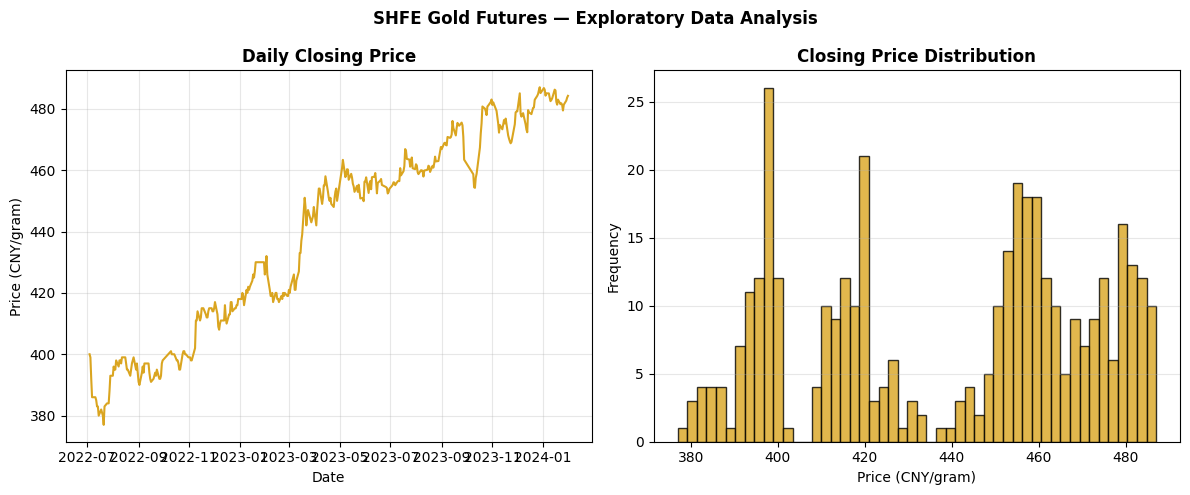

In [46]:
# Two side-by-side plots: price trend and price distribution.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: closing price over time
axes[0].plot(df.index, df['Close'], linewidth=1.5, color='goldenrod')
axes[0].set_title('Daily Closing Price', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (CNY/gram)')
axes[0].grid(True, alpha=0.3)

# Right: histogram of closing prices
axes[1].hist(df['Close'], bins=50, color='goldenrod', edgecolor='black', alpha=0.8)
axes[1].set_title('Closing Price Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price (CNY/gram)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('SHFE Gold Futures — Exploratory Data Analysis',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'eda_gold_closing_price.png'), dpi=150)
plt.show()

Interpretations: 

- Trend: Gold prices rose steadily from around 380 to nearly 490 CNY/gram over the observation period.

- Patterns: The histogram shows a multimodal distribution with three loose clusters around 395, 420, and 455 to 480 CNY/gram, reflecting distinct price phases the market moved through over time.

- Missing Values: There are no missing values across any column, so the dataset is clean and ready for modelling.

- Outliers: The maximum close price of 487 CNY/gram sits noticeably above the 75th percentile of 466, but it does not appear to be a sudden spike and is consistent with the late uptrend.

---

## 2. Time Series Analysis

Check for stationarity (e.g., ADF test) and perform seasonal decomposition to understand the underlying components of the data.

Here we will answer two questions:

1. Is the series stationary?

2. Is there a seasonal pattern? For example, do gold prices behave differently on certain days of the week? We check with seasonal decomposition using a 5-day (weekly trading) cycle and a 22-day (monthly trading) cycle.

In [30]:
# --- ADF test on the raw closing price ---
# We expect this to be NON-stationary (prices drift over time).

def adf_test(series, title=''):
    """Run the Augmented Dickey-Fuller test and print the result."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Test: {title}')
    print(f'  Test Statistic : {result[0]:.6f}')
    print(f'  p-value        : {result[1]:.6f}')
    if result[1] <= 0.05:
        print(f'  Result: Stationary (p <= 0.05)\n')
    else:
        print(f'  Result: NON-Stationary (p > 0.05)\n')
    return result

adf_price = adf_test(df['Close'], 'Raw Closing Price')


ADF Test: Raw Closing Price
  Test Statistic : -0.996949
  p-value        : 0.754375
  Result: NON-Stationary (p > 0.05)



The ADF test on raw closing price proves that it's not stationary.

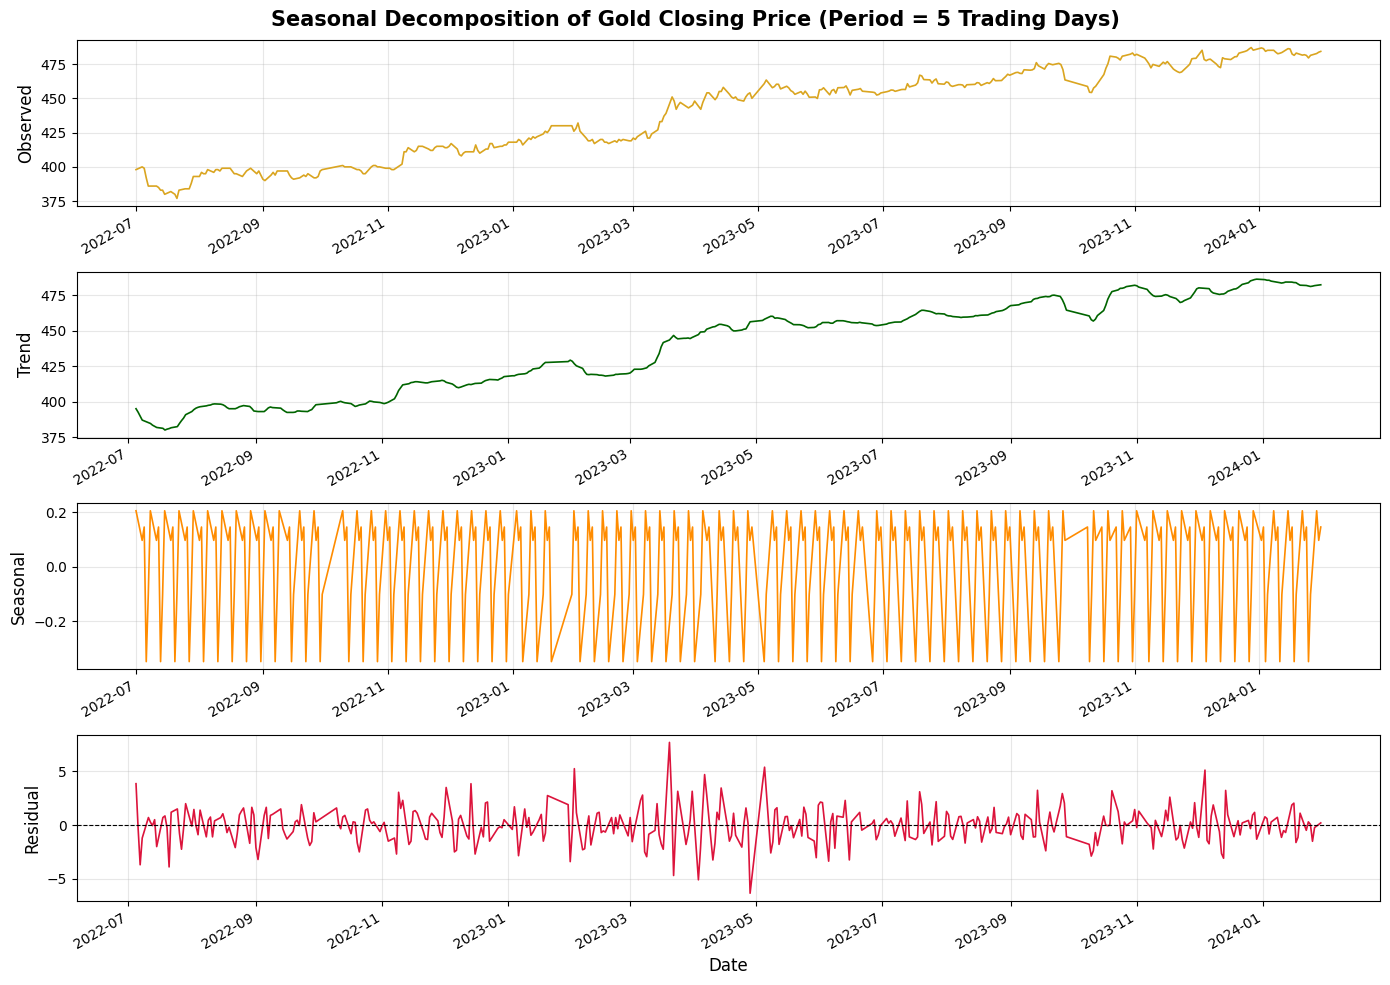

Seasonal strength       : 0.0148  (closer to 1 = stronger)
Seasonal component range: 0.5540 CNY
Residual component range: 14.0493 CNY
Residual / Seasonal     : 25.4x


In [31]:

# --- Seasonal Decomposition (period = 5 trading days = 1 week) ---
decomp = seasonal_decompose(df['Close'].dropna(), model='additive', period=5)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Seasonal Decomposition of Gold Closing Price (Period = 5 Trading Days)',
             fontsize=15, fontweight='bold')

components = [
    (decomp.observed, 'Observed', 'goldenrod'),
    (decomp.trend,    'Trend',    'darkgreen'),
    (decomp.seasonal, 'Seasonal', 'darkorange'),
    (decomp.resid,    'Residual', 'crimson'),
]

for ax, (data, label, color) in zip(axes, components):
    data.plot(ax=ax, color=color, linewidth=1.2)
    ax.set_ylabel(label, fontsize=12)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

axes[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3].set_xlabel('Date', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'weekly_seasonal_decomposition.png'), dpi=150)
plt.show()

# Quantify how strong the seasonal pattern actually is
seasonal_strength = 1 - (decomp.resid.var() / (decomp.resid + decomp.seasonal).var())
seas_range  = decomp.seasonal.max() - decomp.seasonal.min()
resid_range = decomp.resid.dropna().max() - decomp.resid.dropna().min()

print(f'Seasonal strength       : {seasonal_strength:.4f}  (closer to 1 = stronger)')
print(f'Seasonal component range: {seas_range:.4f} CNY')
print(f'Residual component range: {resid_range:.4f} CNY')
print(f'Residual / Seasonal     : {resid_range / seas_range:.1f}x')

Interpretations on the each component:

- Observed: The raw closing price rises steadily from around 375 to 487 CNY/gram, consistent with what was seen in the EDA section.
- Trend: The trend component confirms a smooth and persistent upward movement throughout the entire period with no sign of reversal. There is a noticeable steeper climb between January and May 2023, after which the pace of increase slows down but continues upward.
- Seasonal: The seasonal component shows a regular repeating weekly pattern with swings of roughly ±0.2 CNY, which is extremely small relative to the overall price level. This weak seasonal signal is largely a mathematical artifact of setting period = 5, and does not indicate meaningful weekly seasonality in gold prices. 
- Residual: The residuals fluctuate randomly around zero for most of the period, which is a good sign that the trend and seasonal components have captured the main structure. There are a few larger spikes around early to mid 2023, likely reflecting sudden market reactions to external events rather than any systematic pattern.

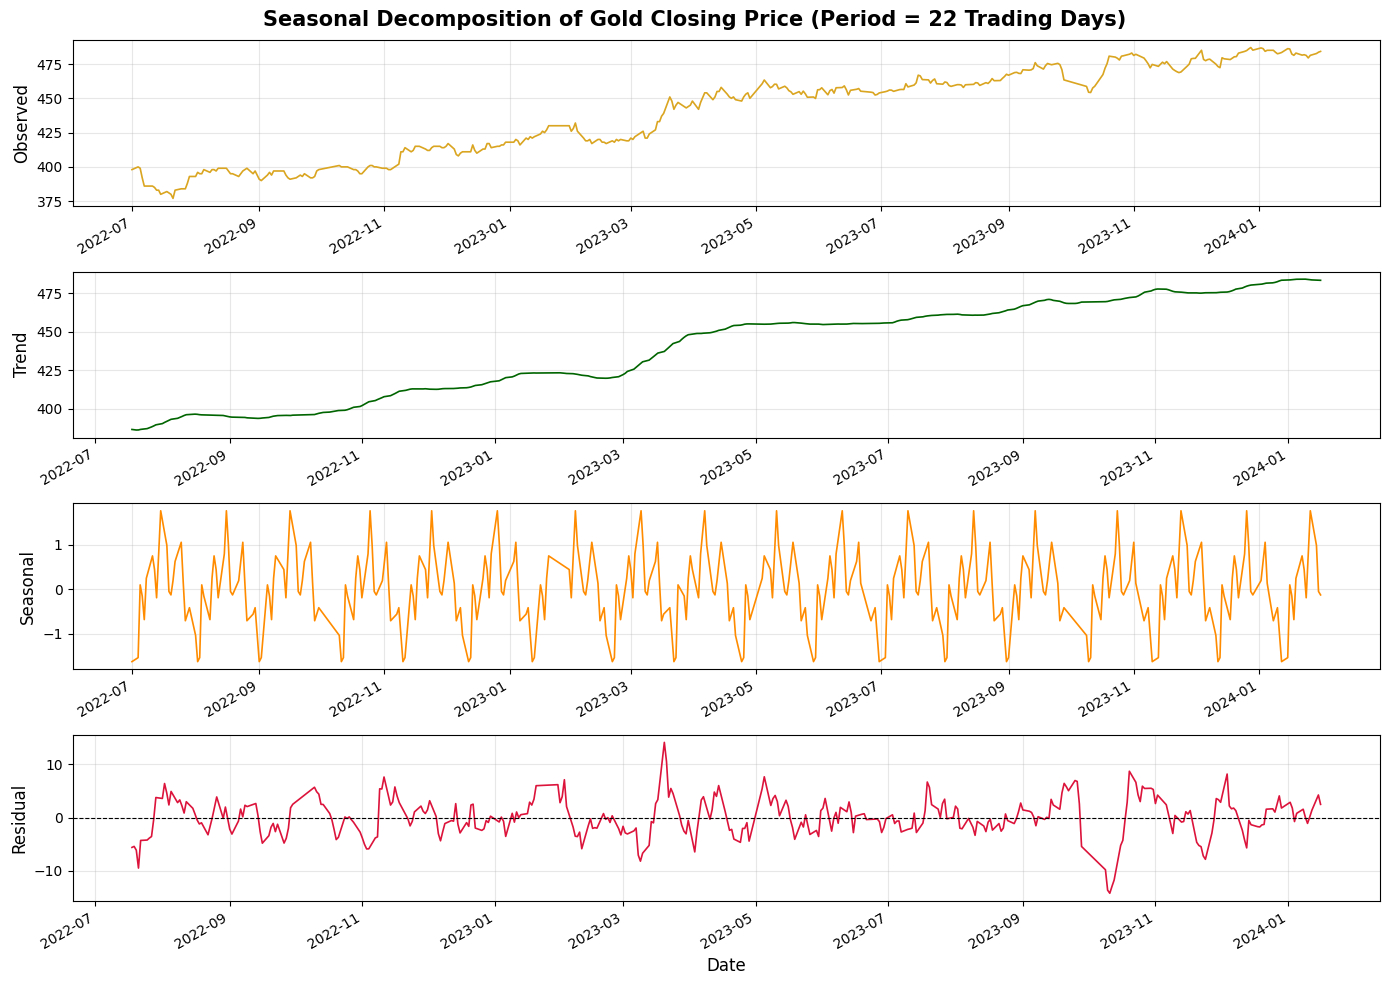

Seasonal strength       : 0.0491  (closer to 1 = stronger)
Seasonal component range: 3.3731 CNY
Residual component range: 28.4128 CNY
Residual / Seasonal     : 8.4x


In [32]:
# --- Seasonal Decomposition (period = 22 trading days = 1 month) ---
decomp_m = seasonal_decompose(df['Close'].dropna(), model='additive', period=22)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Seasonal Decomposition of Gold Closing Price (Period = 22 Trading Days)',
             fontsize=15, fontweight='bold')

components_m = [
    (decomp_m.observed, 'Observed', 'goldenrod'),
    (decomp_m.trend,    'Trend',    'darkgreen'),
    (decomp_m.seasonal, 'Seasonal', 'darkorange'),
    (decomp_m.resid,    'Residual', 'crimson'),
]

for ax, (data, label, color) in zip(axes, components_m):
    data.plot(ax=ax, color=color, linewidth=1.2)
    ax.set_ylabel(label, fontsize=12)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

axes[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3].set_xlabel('Date', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'monthly_seasonal_decomposition.png'), dpi=150)
plt.show()

seasonal_strength_m = 1 - (decomp_m.resid.var() / (decomp_m.resid + decomp_m.seasonal).var())
seas_range_m  = decomp_m.seasonal.max() - decomp_m.seasonal.min()
resid_range_m = decomp_m.resid.dropna().max() - decomp_m.resid.dropna().min()

print(f'Seasonal strength       : {seasonal_strength_m:.4f}  (closer to 1 = stronger)')
print(f'Seasonal component range: {seas_range_m:.4f} CNY')
print(f'Residual component range: {resid_range_m:.4f} CNY')
print(f'Residual / Seasonal     : {resid_range_m / seas_range_m:.1f}x')


The monthly decomposition (period = 22) shows a much smoother, slower-moving trend line compared to the weekly one, because averaging over a full month filters out more short-term noise. The seasonal component in the monthly plot swings between roughly -1.5 and +1.5 CNY, which is about 5 to 7 times larger than the weekly swings of ±0.2 CNY. This suggests there is a slightly more detectable within-month rhythm, but it is still far too weak to justify a SARIMA model. 

Therefore, we would not include a SARIMA model for the data in this project.

---
## 3. Feature Engineering

If applicable, create relevant features such as lag variables, rolling statistics, or calendar-based features to improve model performance.

### From Prices to Log-Returns

The ADF test above confirmed that raw closing prices are non-stationary. ARIMA requires a stationary input, so we need to transform the data.

Instead of calculating the first derivative, here we use **log-returns**, defined as:

$$r_t = \ln(P_t) - \ln(P_{t-1}) = \ln\!\left(\frac{P_t}{P_{t-1}}\right)$$

This can be interpreted as roughly the daily percentage change in price. Log-returns are common for financial time series data, and have two useful properties: they are stationary and can add up over multiple days.

In [33]:
# Compute log-price and log-return, then confirm stationarity with ADF.

df['log_price']  = np.log(df['Close'])
df['log_return'] = df['log_price'].diff()
df.dropna(subset=['log_return'], inplace=True)

print('Log-return statistics:')
print(f'  Mean : {df["log_return"].mean():.6f}')
print(f'  Std  : {df["log_return"].std():.6f}')
print(f'  Obs  : {len(df)}\n')


Log-return statistics:
  Mean : 0.000507
  Std  : 0.005876
  Obs  : 387



In [34]:
# ADF test on log-returns
adf_logret = adf_test(df['log_return'], 'Log-Return Series')


ADF Test: Log-Return Series
  Test Statistic : -8.905950
  p-value        : 0.000000
  Result: Stationary (p <= 0.05)



Through the ADF test, we confirm the log-returns data are stationary and ready for building an ARIMA model.

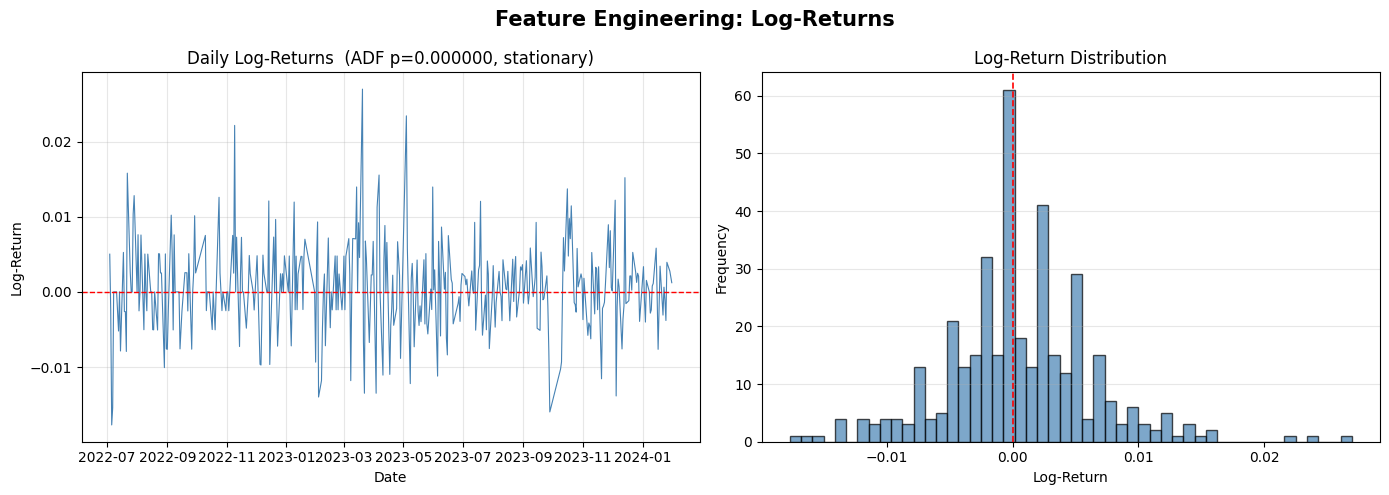

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Engineering: Log-Returns',
             fontsize=15, fontweight='bold')

# Left: Log-returns line chart
axes[0].plot(df.index, df['log_return'], linewidth=0.8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title(f'Daily Log-Returns  (ADF p={adf_logret[1]:.6f}, stationary)', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log-Return')
axes[0].grid(True, alpha=0.3)

# Right: Histogram of log-returns
axes[1].hist(df['log_return'], bins=50, color='steelblue',
             edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Log-Return Distribution', fontsize=12)
axes[1].set_xlabel('Log-Return')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'eda_log_returns.png'), dpi=150)
plt.show()

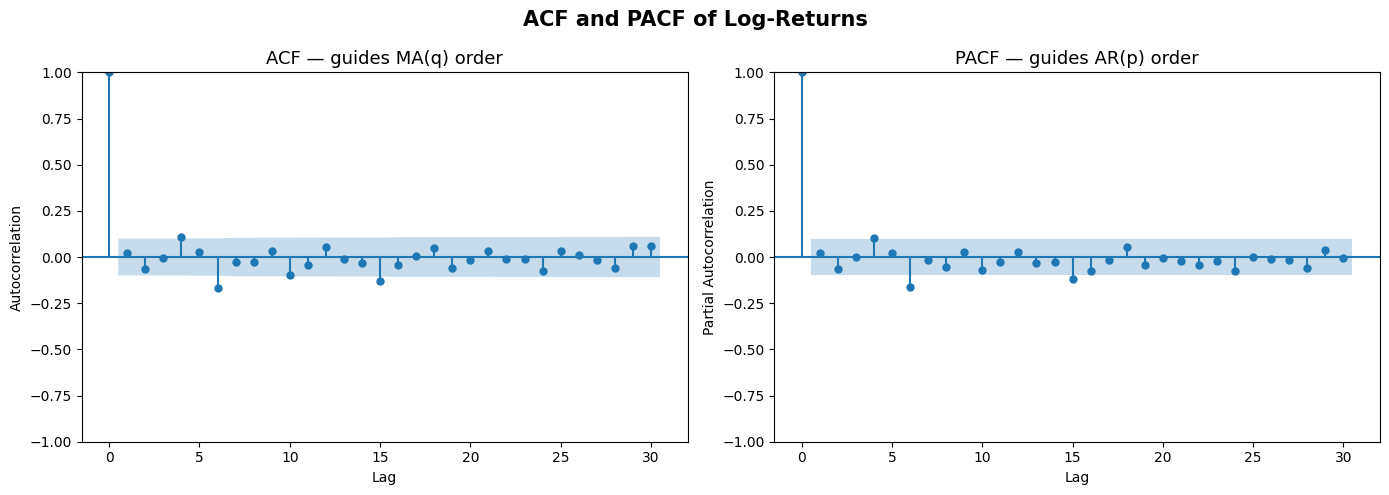

In [36]:
# ACF shows correlation at each lag (guides the MA order).
# PACF shows the direct effect of each lag after removing
# intermediate correlations (guides the AR order).
# We then confirm our choice with an AIC grid search.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ACF and PACF of Log-Returns', fontsize=15, fontweight='bold')

plot_acf(df['log_return'], lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — guides MA(q) order', fontsize=13)
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')

plot_pacf(df['log_return'], lags=30, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — guides AR(p) order', fontsize=13)
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'acf_pacf.png'), dpi=150)
plt.show()


- Almost all lags fall within the confidence band for both ACF and PACF, meaning there is very little linear autocorrelation in the log-returns.
- This suggests low or zero AR(p) and MA(q) orders are appropriate, so starting with ARIMA(0,0,0) or small orders like ARIMA(1,0,0) or ARIMA(0,0,1) is a reasonable approach.

In [37]:

# --- AIC grid search: p in {0,1,2}, q in {0,1,2}, d fixed at 0 ---
print('\nARIMA Order Selection — AIC Grid Search (d=0 fixed):')
print(f'{"Order":<16} {"AIC":>10}')
print('-' * 30)

best_aic   = np.inf
best_order = (1, 0, 1)

for p, q in product(range(3), range(3)):
    if p == 0 and q == 0:
        continue
    try:
        fit = ARIMA(df['log_return'], order=(p, 0, q)).fit()
        marker = '  <-- best so far' if fit.aic < best_aic else ''
        if fit.aic < best_aic:
            best_aic   = fit.aic
            best_order = (p, 0, q)
        print(f'ARIMA({p},0,{q})       {fit.aic:>10.2f}{marker}')
    except Exception as e:
        print(f'ARIMA({p},0,{q})       failed ({e})')

print(f'\nSelected order: ARIMA{best_order}  (AIC = {best_aic:.2f})')


ARIMA Order Selection — AIC Grid Search (d=0 fixed):
Order                   AIC
------------------------------
ARIMA(0,0,1)         -2872.82  <-- best so far
ARIMA(0,0,2)         -2871.83
ARIMA(1,0,0)         -2872.80
ARIMA(1,0,1)         -2870.99
ARIMA(1,0,2)         -2869.68
ARIMA(2,0,0)         -2872.52
ARIMA(2,0,1)         -2870.50
ARIMA(2,0,2)         -2866.65

Selected order: ARIMA(0, 0, 1)  (AIC = -2872.82)


We will use ARIMA(0, 0, 1) and GARCH for modeling.

---
## 4. Modeling

### Expanding Window Approach

Instead of a simple 80/20 train-test split, we use an expanding-window rolling forecast:

- We start with an initial training window of 250 trading days (~1 year).
- At each step, the model is trained on all data up to yesterday and asked to predict the next h days.
- The window slides forward by one day, and we repeat.
- This gives us hundreds of independent, genuinely out-of-sample predictions — none of which peek at future data.

We evaluate at two horizons:
- **h = 1** — can the model predict tomorrow's price?
- **h = 20** — can it predict the price roughly one trading month ahead?

At each step, the model predicts **log-returns**, and we convert them back to closing prices:

$$\hat{P}_{t+k} = P_{t-1} \cdot e^{\hat{r}_t + \hat{r}_{t+1} + \cdots + \hat{r}_{t+k-1}}$$

In [38]:
# Set up the rolling evaluation parameters and define the reusable loop.

h_short = 1          # short-term horizon: next trading day
h_long  = 20         # long-term horizon: ~1 trading month
initial_window = 250 # burn-in: ~1 year of trading days

series = df['log_return']   # stationary modelling target
prices = df['Close']        # for price reconstruction
n = len(series)

print(f'Total observations      : {n}')
print(f'Initial training window : {initial_window}  (~{initial_window/252:.1f} trading years)')
print(f'Rolling evaluation steps: {n - initial_window - h_long}')


def rolling_forecast(fit_predict_fn, horizons, series, prices, initial_window):
    """
    Expanding-window rolling forecast loop.

    fit_predict_fn : callable(train_series, h_max) -> {'mean': array of length h_max}
        Fits a model on training data and returns predicted log-returns.
    horizons : list of int
        Forecast horizons to evaluate (e.g. [1, 20]).

    Returns dict : {horizon: {'fc_prices': array, 'act_prices': array, 'times': list}}
    """
    h_max = max(horizons)
    n = len(series)
    results = {h: {'fc_prices': [], 'act_prices': [], 'times': []}
              for h in horizons}

    total = n - initial_window - h_max

    for idx, t in enumerate(range(initial_window, n - h_max)):
        train_s    = series.iloc[:t]
        last_price = prices.iloc[t - 1]

        out     = fit_predict_fn(train_s, h_max)
        fc_rets = out['mean']

        for h in horizons:
            cum_ret  = np.cumsum(fc_rets[:h])
            price_fc = last_price * np.exp(cum_ret)
            actual   = prices.iloc[t:t + h].values

            results[h]['fc_prices'].append(price_fc)
            results[h]['act_prices'].append(actual)
            results[h]['times'].append(series.index[t])

        if idx % 50 == 0:
            print(f'  Step {idx}/{total} ({idx/total*100:.0f}%)')

    # Convert lists to numpy arrays
    for h in horizons:
        results[h]['fc_prices']  = np.array(results[h]['fc_prices'])
        results[h]['act_prices'] = np.array(results[h]['act_prices'])

    return results

print('\nRolling forecast function defined.')

Total observations      : 387
Initial training window : 250  (~1.0 trading years)
Rolling evaluation steps: 117

Rolling forecast function defined.


### ARIMA

We use ARIMA(0, 0, 1) based on the results from the last section.

In [39]:
# Fit ARIMA at each rolling step and collect predictions.

def arima_predict(train, h_max):
    model = ARIMA(train, order=best_order)
    fit   = model.fit()
    return {'mean': fit.forecast(steps=h_max).values}

print(f'Running rolling ARIMA{best_order} ...')
arima_res = rolling_forecast(arima_predict, [h_short, h_long],
                             series, prices, initial_window)
print('ARIMA rolling evaluation complete.')

Running rolling ARIMA(0, 0, 1) ...
  Step 0/117 (0%)
  Step 50/117 (43%)
  Step 100/117 (85%)
ARIMA rolling evaluation complete.


### GARCH

We use GARCH(1, 1) with Student-t errors.

GARCH is designed to capture volatility clustering: turbulent market periods tend to be followed by more turbulence, and calm periods stay calm.

Unlike ARIMA, GARCH produces both a mean forecast (predicted return) and a variance forecast (how uncertain the market is right now).

In [40]:
# Fit GARCH(1,1) with Student-t errors at each rolling step.

def garch_predict(train, h_max):
    model = arch_model(train * 100, p=1, q=1, mean='AR', lags=1, dist='t')
    fit   = model.fit(disp='off')
    fc    = fit.forecast(horizon=h_max)
    mean_fc = fc.mean.iloc[-1].values / 100   
    # undo x100 scaling: multiplying log-returns by 100 before fitting improves numerical stability; we divide back afterwards.
    return {'mean': mean_fc}

print('Running rolling GARCH(1,1)-t ...')
garch_res = rolling_forecast(garch_predict, [h_short, h_long],
                             series, prices, initial_window)
print('GARCH rolling evaluation complete.')

Running rolling GARCH(1,1)-t ...
  Step 0/117 (0%)
  Step 50/117 (43%)
  Step 100/117 (85%)
GARCH rolling evaluation complete.


---
## 5. Model Evaluation

We compare ARIMA and GARCH using two metrics:

- RMSE — in the same unit as price (CNY/gram). It penalises large errors more heavily.
- MAE — the average size of the forecast miss, also in CNY/gram. More robust to outliers than RMSE.

Both metrics are computed separately for:
- h = 1 — next-day price prediction (using the single predicted price).
- h = 20 — 20-day-ahead price prediction (using the price at the end of the 20-step forecast path, not a pooled average).

In [41]:
# Compare the two models on RMSE and MAE at both horizons.

def compute_rmse(act, fc):
    return np.sqrt(np.mean((act - fc) ** 2))

def compute_mae(act, fc):
    return np.mean(np.abs(act - fc))

metrics = {}

for name, res in [('ARIMA', arima_res), ('GARCH', garch_res)]:
    m = {}
    m['RMSE_h1']  = compute_rmse(res[h_short]['act_prices'][:, 0],
                                  res[h_short]['fc_prices'][:, 0])
    m['MAE_h1']   = compute_mae( res[h_short]['act_prices'][:, 0],
                                  res[h_short]['fc_prices'][:, 0])
    m['RMSE_h20'] = compute_rmse(res[h_long]['act_prices'][:, -1],
                                  res[h_long]['fc_prices'][:, -1])
    m['MAE_h20']  = compute_mae( res[h_long]['act_prices'][:, -1],
                                  res[h_long]['fc_prices'][:, -1])
    metrics[name] = m

print('Average prediction error across all rolling windows:')
print(f'{"Model":<10} {"RMSE h=1":>10} {"MAE h=1":>11} {"RMSE h=20":>11} {"MAE h=20":>10}')
for name in ['ARIMA', 'GARCH']:
    m = metrics[name]
    print(f'{name:<10} {m["RMSE_h1"]:>10.4f} {m["MAE_h1"]:>9.4f} '
        f'{m["RMSE_h20"]:>11.4f} {m["MAE_h20"]:>10.4f} ')
print('=' * 50)

print(f'Best model at h=1  : {min(metrics, key=lambda m: metrics[m]["RMSE_h1"])}')
print(f'Best model at h=20 : {min(metrics, key=lambda m: metrics[m]["RMSE_h20"])}')


Average prediction error across all rolling windows:
Model        RMSE h=1     MAE h=1   RMSE h=20   MAE h=20
ARIMA          2.4652    1.8330      7.9041     6.3699 
GARCH          2.4787    1.8438      7.7729     6.3508 
Best model at h=1  : ARIMA
Best model at h=20 : GARCH


**Model Comparison Interpretation**

- Both models perform very similarly overall, with differences in RMSE and MAE being marginal, so neither model is dramatically better than the other.
- At the 1-day horizon, ARIMA edges out GARCH slightly on both metrics, suggesting ARIMA captures short-term mean movements marginally better.
- At the 20-day horizon, GARCH performs slightly better on both metrics, which makes sense because GARCH is designed to model changing volatility over time and this advantage becomes more visible as the forecast window grows longer.

---
## 6. Forecasting & Visualization

We first look back at how each model tracked reality during the rolling evaluation, then look forward with a fresh 20-day forecast including confidence intervals.

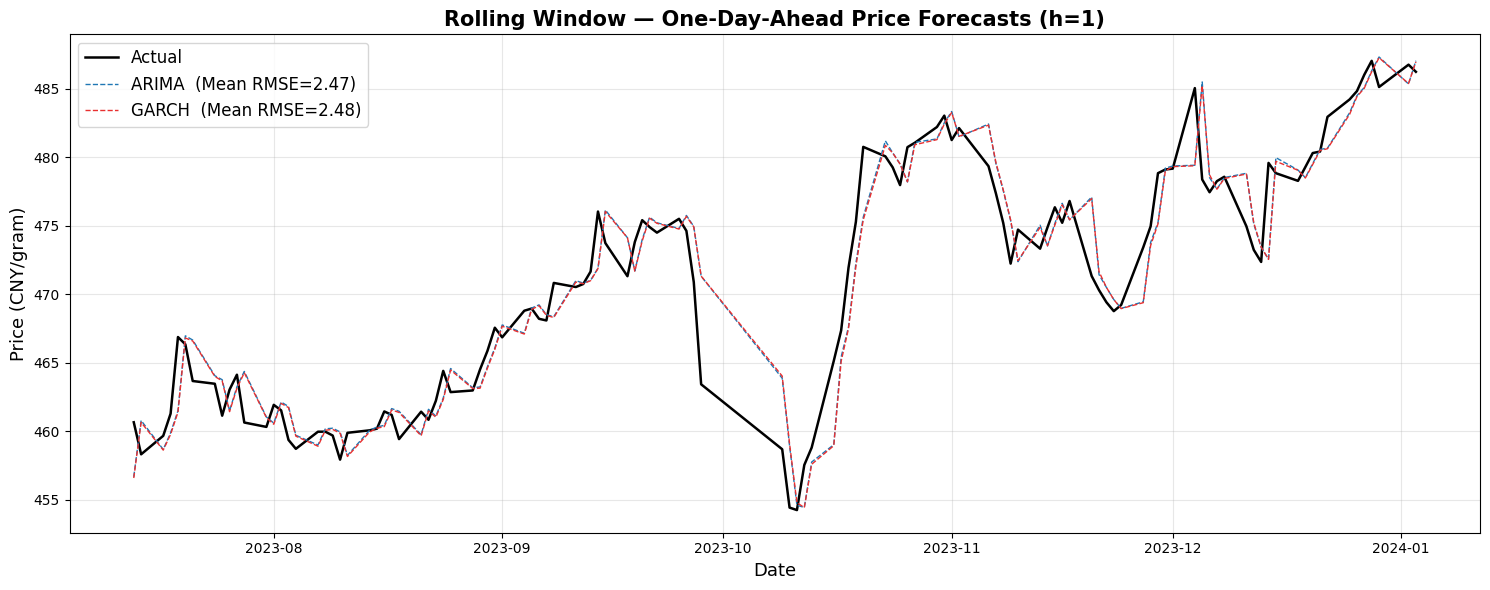

In [42]:
# Visualise how ARIMA and GARCH predictions compared to actual prices
# during the rolling evaluation period.

COLORS = {'Actual': '#000000', 'ARIMA': '#1F77B4', 'GARCH': '#E83030'}

# --- Chart 1: h=1 (next-day forecasts) ---
fig, ax = plt.subplots(figsize=(15, 6))
times = pd.DatetimeIndex(arima_res[h_short]['times'])

ax.plot(times, arima_res[h_short]['act_prices'][:, 0],
        color=COLORS['Actual'], linewidth=1.8, label='Actual')
ax.plot(times, arima_res[h_short]['fc_prices'][:, 0],
        '--', color=COLORS['ARIMA'], linewidth=1,
        label=f'ARIMA  (Mean RMSE={metrics["ARIMA"]["RMSE_h1"]:.2f})')
ax.plot(times, garch_res[h_short]['fc_prices'][:, 0],
        '--', color=COLORS['GARCH'], linewidth=1,
        label=f'GARCH  (Mean RMSE={metrics["GARCH"]["RMSE_h1"]:.2f})')

ax.set_title('Rolling Window — One-Day-Ahead Price Forecasts (h=1)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Price (CNY/gram)', fontsize=13)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'rolling_forecasts_h1.png'), dpi=150)
plt.show()


Both ARIMA and GARCH forecasts are nearly identical and track the actual price very closely, with the two dashed lines almost completely overlapping throughout the entire period.

At h=1, both models are essentially just using yesterday's price as the base and adding a tiny predicted log-return, so there is almost no room for the two models to diverge from each other.

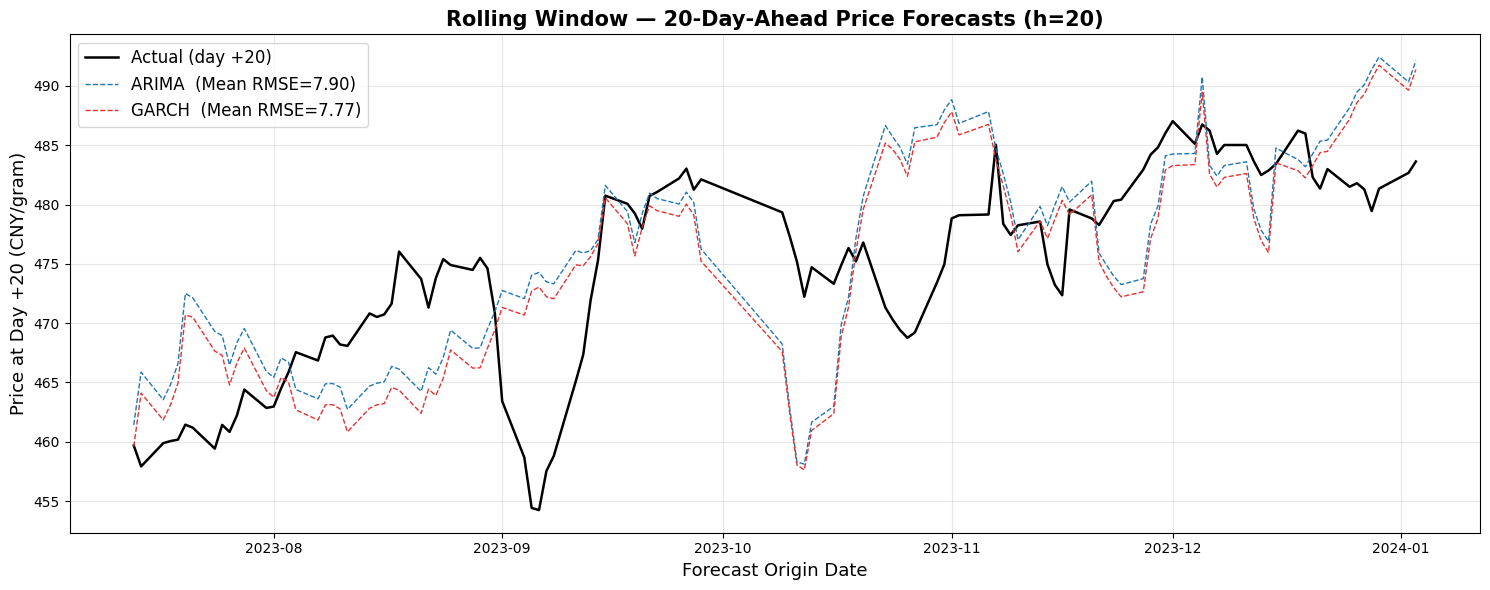

In [43]:

# --- Chart 2: h=20 (20-day-ahead forecasts) ---
fig, ax = plt.subplots(figsize=(15, 6))
times_20 = pd.DatetimeIndex(arima_res[h_long]['times'])

ax.plot(times_20, arima_res[h_long]['act_prices'][:, -1],
        color=COLORS['Actual'], linewidth=1.8, label='Actual (day +20)')
ax.plot(times_20, arima_res[h_long]['fc_prices'][:, -1],
        '--', color=COLORS['ARIMA'], linewidth=1,
        label=f'ARIMA  (Mean RMSE={metrics["ARIMA"]["RMSE_h20"]:.2f})')
ax.plot(times_20, garch_res[h_long]['fc_prices'][:, -1],
        '--', color=COLORS['GARCH'], linewidth=1,
        label=f'GARCH  (Mean RMSE={metrics["GARCH"]["RMSE_h20"]:.2f})')

ax.set_title('Rolling Window — 20-Day-Ahead Price Forecasts (h=20)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Forecast Origin Date', fontsize=13)
ax.set_ylabel('Price at Day +20 (CNY/gram)', fontsize=13)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'rolling_forecasts_h20.png'), dpi=150)
plt.show()

The two models show more visible separation at h=20, with GARCH generally producing slightly different price paths than ARIMA, reflecting how GARCH accounts for changing volatility when projecting further into the future.

Both models struggle more at this horizon, sometimes overshooting or undershooting the actual price by a noticeable margin, which is expected since uncertainty compounds over 20 days.

Train size : 348 observations  (2022-07-04 to 2023-12-06)
Test size  : 39  observations  (2023-12-07 to 2024-01-31)


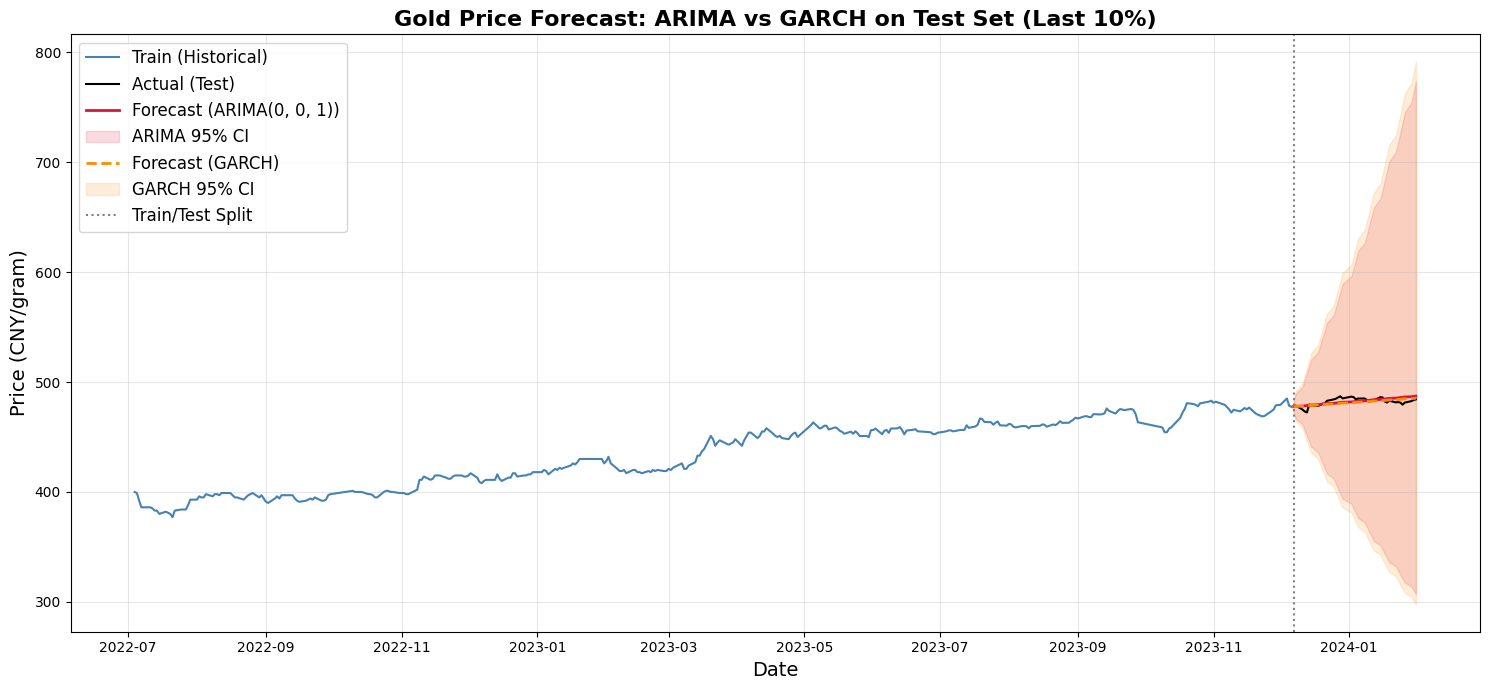

Last train price      : 477.44 CNY/gram  (2023-12-06)
ARIMA forecast end    : 487.19 CNY/gram
GARCH forecast end    : 485.32 CNY/gram
Actual end price      : 484.22 CNY/gram  (2024-01-31)


In [44]:
# Train-test split: 90% train, 10% test
split_idx   = int(len(series) * 0.9)
train_series = series.iloc[:split_idx]
test_series  = series.iloc[split_idx:]
train_prices = prices.iloc[:split_idx]
test_prices  = prices.iloc[split_idx:]

print(f'Train size : {len(train_series)} observations  ({train_series.index[0].date()} to {train_series.index[-1].date()})')
print(f'Test size  : {len(test_series)}  observations  ({test_series.index[0].date()} to {test_series.index[-1].date()})')

# --- Fit ARIMA on train set ---
arima_final  = ARIMA(train_series, order=best_order).fit()
arima_fc     = arima_final.get_forecast(steps=len(test_series))
arima_mean   = arima_fc.predicted_mean
arima_ci     = arima_fc.conf_int()

# Convert ARIMA log-return forecasts to price levels
last_train_price = train_prices.iloc[-1]
arima_prices     = last_train_price * np.exp(np.cumsum(arima_mean.values))
arima_lower      = last_train_price * np.exp(np.cumsum(arima_ci.iloc[:, 0].values))
arima_upper      = last_train_price * np.exp(np.cumsum(arima_ci.iloc[:, 1].values))

# --- Fit GARCH on train set (same spec as rolling evaluation) ---
garch_final  = arch_model(train_series * 100, mean='AR', lags=1, p=1, q=1, dist='t').fit(disp='off')
garch_fc     = garch_final.forecast(horizon=len(test_series), reindex=False)

# GARCH mean forecast and variance-based CI (undo x100 scaling)
garch_mean_rets = garch_fc.mean.iloc[-1].values / 100
garch_vol       = np.sqrt(garch_fc.variance.iloc[-1].values) / 100
garch_prices    = last_train_price * np.exp(np.cumsum(garch_mean_rets))
garch_lower     = last_train_price * np.exp(np.cumsum(garch_mean_rets - 1.96 * garch_vol))
garch_upper     = last_train_price * np.exp(np.cumsum(garch_mean_rets + 1.96 * garch_vol))

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(train_prices.index, train_prices.values,
        color='steelblue', linewidth=1.5, label='Train (Historical)')
ax.plot(test_prices.index, test_prices.values,
        color='black', linewidth=1.5, label='Actual (Test)')

# ARIMA forecast
ax.plot(test_prices.index, arima_prices,
        color='crimson', linewidth=2, label=f'Forecast (ARIMA{best_order})')
ax.fill_between(test_prices.index, arima_lower, arima_upper,
                color='crimson', alpha=0.15, label='ARIMA 95% CI')

# GARCH forecast
ax.plot(test_prices.index, garch_prices,
        color='darkorange', linewidth=2, linestyle='--', label='Forecast (GARCH)')
ax.fill_between(test_prices.index, garch_lower, garch_upper,
                color='darkorange', alpha=0.15, label='GARCH 95% CI')

# Connecting lines
ax.plot([train_prices.index[-1], test_prices.index[0]],
        [train_prices.values[-1], arima_prices[0]],
        color='crimson', linewidth=2, linestyle='--', alpha=0.5)
ax.plot([train_prices.index[-1], test_prices.index[0]],
        [train_prices.values[-1], garch_prices[0]],
        color='darkorange', linewidth=2, linestyle='--', alpha=0.5)

ax.axvline(test_prices.index[0], color='grey',
           linestyle=':', linewidth=1.5, label='Train/Test Split')

ax.set_title('Gold Price Forecast: ARIMA vs GARCH on Test Set (Last 10%)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Price (CNY/gram)', fontsize=14)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'forecast_split.png'), dpi=150)
plt.show()

# Summary
print(f'Last train price      : {last_train_price:.2f} CNY/gram  ({train_prices.index[-1].date()})')
print(f'ARIMA forecast end    : {arima_prices[-1]:.2f} CNY/gram')
print(f'GARCH forecast end    : {garch_prices[-1]:.2f} CNY/gram')
print(f'Actual end price      : {test_prices.iloc[-1]:.2f} CNY/gram  ({test_prices.index[-1].date()})')
